<a href="https://colab.research.google.com/github/Istiaq-Alam/Student-Performance-Prediction-with-Explainable-AI/blob/main/CodeBase/Trial2.0/Full_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm shap lime joblib flask flask-cors

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=456d020e7d2aeb02e9d52a9fe2ae5f9d8b36ad9f899e27aa2a51d6f53e6f5f49
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


(2000, 7)
        Assignment  Presentation   Attendance         Quiz      MidTerm  \
count  2000.000000   2000.000000  2000.000000  2000.000000  2000.000000   
mean      5.597500      5.596500     5.664500     3.899000     8.240500   
std       2.823381      2.871029     2.968391     2.353841     4.387629   
min       0.000000      0.000000     0.000000     0.000000     0.000000   
25%       3.000000      3.000000     3.000000     2.000000     5.000000   
50%       6.000000      6.000000     6.000000     4.000000     8.000000   
75%       8.000000      8.000000     8.000000     6.000000    12.000000   
max      10.000000     10.000000    10.000000    10.000000    20.000000   

             Final         CGPA  
count  2000.000000  2000.000000  
mean     19.185000     2.409500  
std       9.603848     0.948754  
min       0.000000     1.250000  
25%      12.000000     1.500000  
50%      19.000000     2.250000  
75%      27.000000     3.250000  
max      40.000000     4.000000  
Assignme

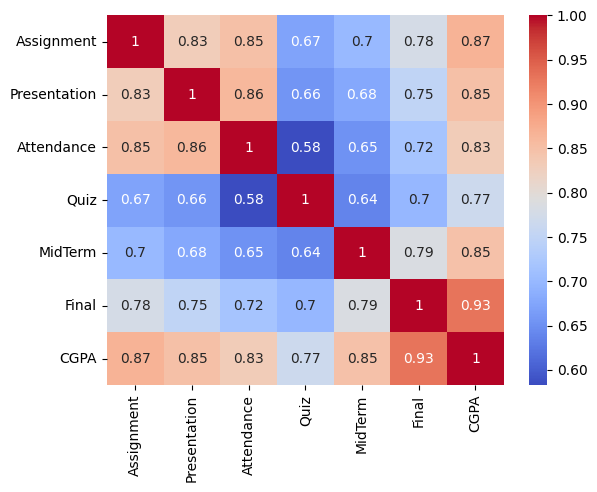

In [2]:
# Load & explore data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('result-data.csv')

print(df.shape)
print(df.describe())
print(df.isnull().sum())
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [3]:
# Define Features & Targets

FEATURES = ['Assignment', 'Presentation', 'Attendance', 'Quiz', 'MidTerm']
X = df[FEATURES]
y_final = df['Final']       # regression target
y_cgpa  = df['CGPA']        # regression target

In [4]:
# Model Training
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y_final, test_size=0.2, random_state=42
)

models = {
    'XGBoost':       XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    'RandomForest':  RandomForestRegressor(n_estimators=200, random_state=42),
    'LightGBM':      LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{name}: MAE={mean_absolute_error(y_test,preds):.3f}  R2={r2_score(y_test,preds):.3f}")

XGBoost: MAE=4.004  R2=0.709
RandomForest: MAE=4.068  R2=0.697
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 65
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 5
[LightGBM] [Info] Start training from score 19.028750
LightGBM: MAE=4.050  R2=0.710


In [5]:
# CGPA tier prediction (classification layer on top):

# Map CGPA to grade tier for classification
def cgpa_to_tier(cgpa):
    if cgpa >= 4.00: return 'A+ (4.00)'
    elif cgpa >= 3.90: return 'A (3.90)'
    elif cgpa >= 3.80: return 'A- (3.80)'
    elif cgpa >= 3.75: return 'B+ (3.75)'
    else: return 'Below 3.75'

df['Tier'] = df['CGPA'].apply(cgpa_to_tier)

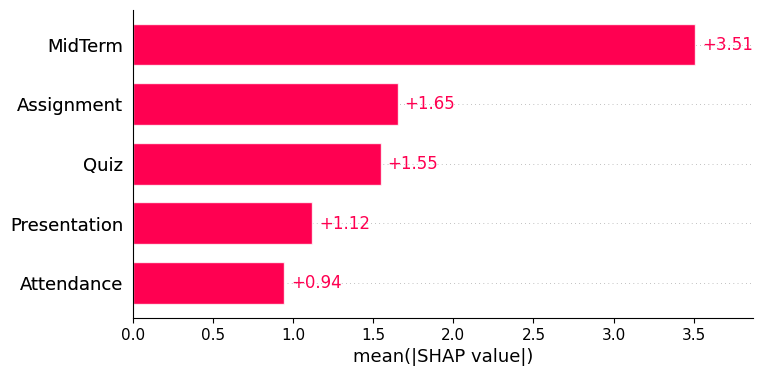

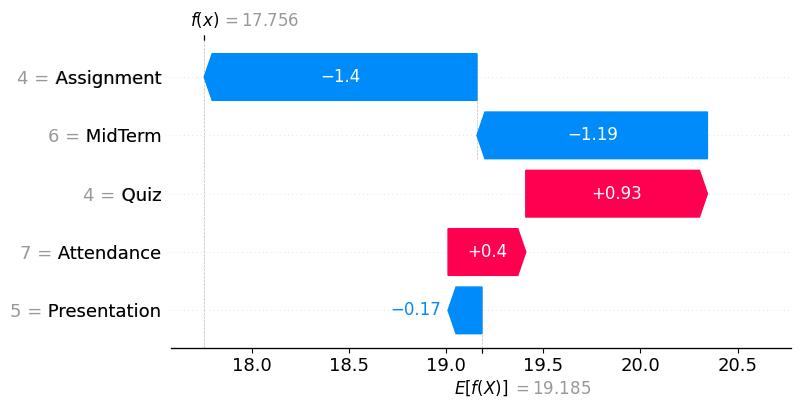

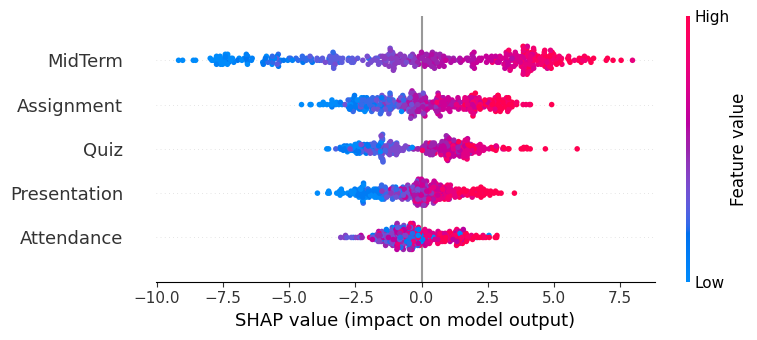

In [6]:
# XAI with SHAP + LIME

import shap

best_model = models['XGBoost']  # use whichever wins
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

# Global importance
shap.plots.bar(shap_values)

# Per-student waterfall (student index 0)
shap.plots.waterfall(shap_values[0])

# Summary plot
shap.summary_plot(shap_values, X_test)

In [7]:
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=FEATURES,
    mode='regression'
)

# Explain one student's prediction
instance = X_test.iloc[0].values
exp = lime_explainer.explain_instance(instance, best_model.predict)
exp.show_in_notebook()

In [13]:
def cgpa_from_total(total_marks):
    """Approximate CGPA from total course marks (customize to your grading policy)."""
    if total_marks >= 90: return 4.00
    elif total_marks >= 85: return 3.90
    elif total_marks >= 80: return 3.80
    elif total_marks >= 75: return 3.75
    else: return round(total_marks / 25, 2)

def study_advisor(assignment, presentation, attendance, quiz, midterm, model):
    current_features = np.array([[assignment, presentation, attendance, quiz, midterm]])
    predicted_final = model.predict(current_features)[0]

    current_total = assignment + presentation + attendance + quiz + midterm + predicted_final
    predicted_cgpa = cgpa_from_total(current_total)

    CGPA_TARGETS = [4.00, 3.90, 3.80, 3.75]
    TOTAL_NEEDED  = [90,   85,   80,   75]

    advice = []
    current_non_final = assignment + presentation + attendance + quiz + midterm

    for target_cgpa, total_needed in zip(CGPA_TARGETS, TOTAL_NEEDED):
        final_needed = total_needed - current_non_final
        final_needed = max(0, min(40, final_needed))  # clamp to valid range

        if final_needed <= 40:
            gap = max(0, final_needed - predicted_final)
            hours = round(gap * 1.5 + 5, 1)  # rough study-hour formula
            advice.append({
                'target_cgpa': target_cgpa,
                'final_needed': round(final_needed, 1),
                'gap_from_predicted': round(gap, 1),
                'study_hours_needed': hours,
                'achievable': final_needed <= 40
            })

    return predicted_final, predicted_cgpa, advice

In [14]:
import ipywidgets as widgets
from IPython.display import display

def interactive_predictor(assignment, presentation, attendance, quiz, midterm):
    pred_final, pred_cgpa, advice = study_advisor(
        assignment, presentation, attendance, quiz, midterm, best_model
    )
    # Confidence: use model's cross-val R2 as proxy accuracy
    cv_score = cross_val_score(best_model, X, y_final, cv=5, scoring='r2').mean()

    print(f"Predicted Final Score : {pred_final:.1f} / 40")
    print(f"Predicted CGPA        : {pred_cgpa}")
    print(f"Model Accuracy (R²)   : {cv_score*100:.1f}%\n")
    print("--- Study Roadmap ---")
    for a in advice:
        print(f"  CGPA {a['target_cgpa']} → need {a['final_needed']}/40 in Final "
              f"| Gap: {a['gap_from_predicted']} marks | Study: ~{a['study_hours_needed']} hrs")

widgets.interact(
    interactive_predictor,
    assignment=widgets.IntSlider(min=0, max=10, value=7),
    presentation=widgets.IntSlider(min=0, max=10, value=7),
    attendance=widgets.IntSlider(min=0, max=10, value=8),
    quiz=widgets.IntSlider(min=0, max=10, value=6),
    midterm=widgets.IntSlider(min=0, max=20, value=12),
)

interactive(children=(IntSlider(value=7, description='assignment', max=10), IntSlider(value=7, description='pr…

<function __main__.interactive_predictor(assignment, presentation, attendance, quiz, midterm)>

In [11]:
# model saving
import joblib
joblib.dump(best_model, 'model.pkl')
joblib.dump(explainer, 'shap_explainer.pkl')

['shap_explainer.pkl']

✅ All libraries loaded successfully.
Dataset shape   : (2000, 7)
Training samples: 1600
Test samples    : 400

Feature ranges:
       Assignment  Presentation  Attendance     Quiz  MidTerm    Final
count     2000.00       2000.00     2000.00  2000.00  2000.00  2000.00
mean         5.60          5.60        5.66     3.90     8.24    19.18
std          2.82          2.87        2.97     2.35     4.39     9.60
min          0.00          0.00        0.00     0.00     0.00     0.00
25%          3.00          3.00        3.00     2.00     5.00    12.00
50%          6.00          6.00        6.00     4.00     8.00    19.00
75%          8.00          8.00        8.00     6.00    12.00    27.00
max         10.00         10.00       10.00    10.00    20.00    40.00
  MODEL SELECTION RATIONALE

▶ Linear Regression
  Baseline model. Assumes a straight-line relationship between 
  features and Final score. Fast and interpretable, but 
  struggles with non-linear patterns common in student 
  perfor

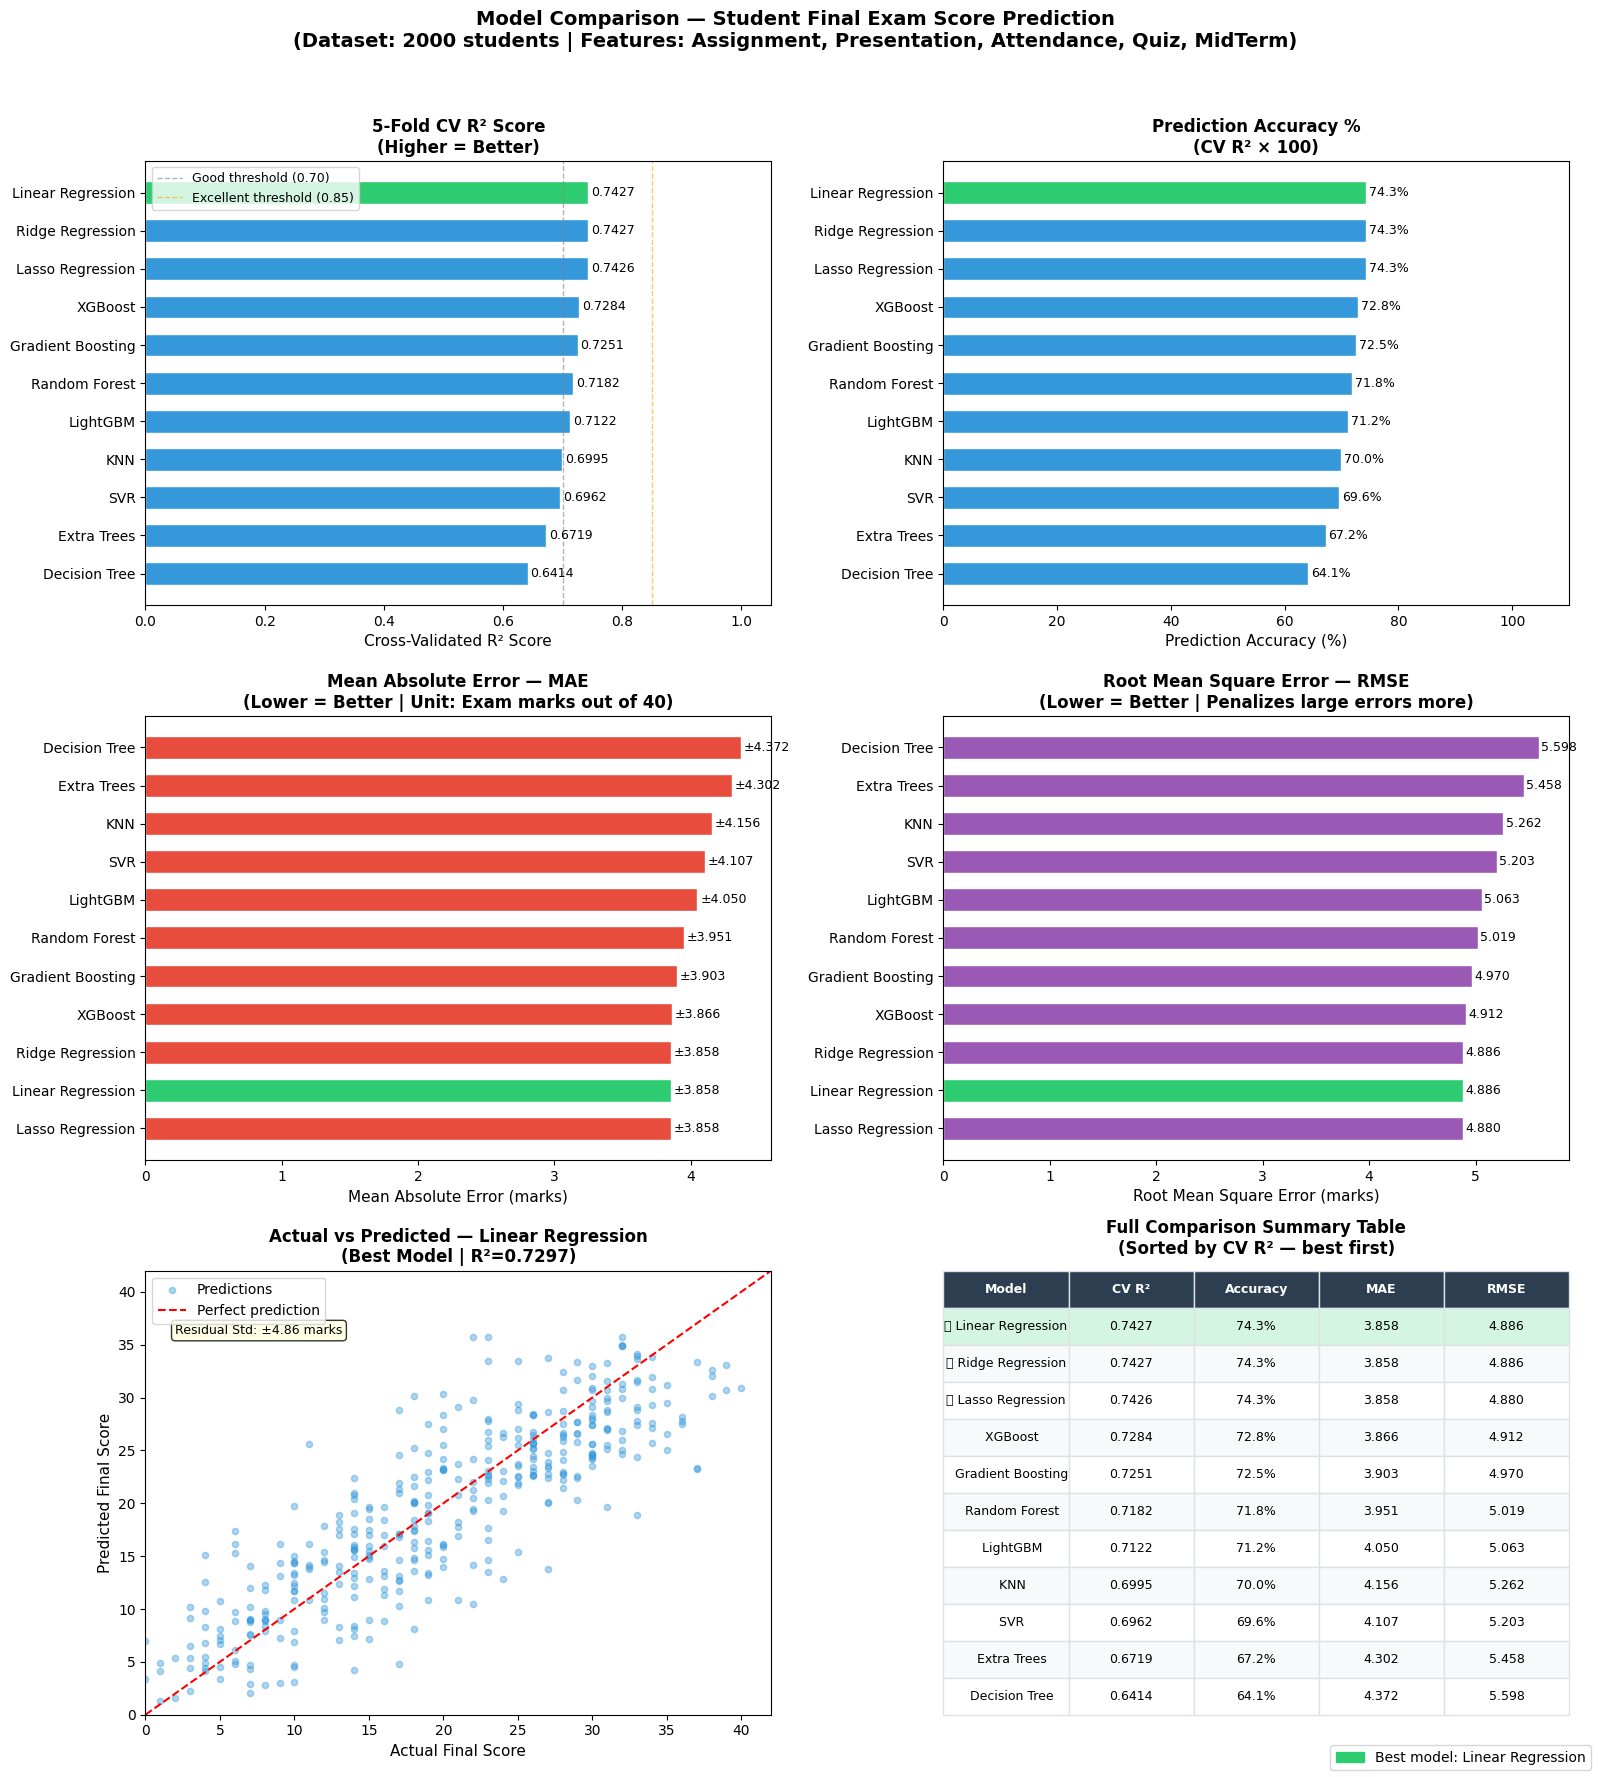

✅ Plot saved as model_comparison.png

╔══════════════════════════════════════════════════════════════╗
║           METRIC DEFINITIONS (for thesis writing)           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  R² (R-squared / Coefficient of Determination)              ║
║  ─────────────────────────────────────────────               ║
║  Range: 0.0 to 1.0  (higher is better)                      ║
║  0.73 means the model explains 73% of variance in           ║
║  Final scores. We use 5-fold CV R² for fair comparison.     ║
║                                                              ║
║  Accuracy % = CV R² × 100                                   ║
║  ─────────────────────────────────────────────               ║
║  Human-readable form of R². A model with R²=0.7325          ║
║  has ~73.25% prediction accuracy for this dataset.          ║
║                                                           

In [15]:
# ============================================================
# CELL 1 — Imports & Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Install if not already present
# !pip install xgboost lightgbm
try:
    from xgboost import XGBRegressor
    from lightgbm import LGBMRegressor
    HAS_BOOST = True
except ImportError:
    HAS_BOOST = False
    print("Note: xgboost/lightgbm not installed — running without them.")

print("✅ All libraries loaded successfully.")


# ============================================================
# CELL 2 — Load Dataset
# ============================================================
df = pd.read_csv('result-data.csv')

FEATURES = ['Assignment', 'Presentation', 'Attendance', 'Quiz', 'MidTerm']
TARGET   = 'Final'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset shape   : {df.shape}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples    : {X_test.shape[0]}")
print(f"\nFeature ranges:")
print(df[FEATURES + [TARGET]].describe().round(2))


# ============================================================
# CELL 3 — Why Each Model? (Printed explanation)
# ============================================================
model_rationale = {
    "Linear Regression": (
        "Baseline model. Assumes a straight-line relationship between features and "
        "Final score. Fast and interpretable, but struggles with non-linear patterns "
        "common in student performance data."
    ),
    "Ridge Regression": (
        "Extends Linear Regression with L2 regularization to prevent overfitting when "
        "features are correlated (e.g., Assignment & Presentation often move together). "
        "Keeps all features but shrinks their coefficients."
    ),
    "Lasso Regression": (
        "L1 regularization that can zero out weak features entirely — useful for "
        "automatic feature selection. Tells us which features matter least."
    ),
    "Decision Tree": (
        "Splits data using if-else rules on feature thresholds. Highly interpretable — "
        "easy to visualize. Tends to overfit without depth limits, which is why ensemble "
        "methods (Random Forest) were developed."
    ),
    "Random Forest": (
        "Builds 200 independent decision trees and averages their predictions. Reduces "
        "variance from single trees. Excellent for tabular educational data — handles "
        "non-linear relationships and feature interactions naturally."
    ),
    "Gradient Boosting": (
        "Builds trees sequentially — each tree corrects the errors of the previous one. "
        "Often achieves the highest accuracy on structured data. Slower to train but "
        "more precise. Industry standard for tabular prediction tasks."
    ),
    "Extra Trees": (
        "Similar to Random Forest but splits are chosen randomly rather than optimally. "
        "Faster and sometimes more robust to noisy data. Good comparison point against "
        "Random Forest."
    ),
    "K-Nearest Neighbors": (
        "Predicts based on the k=5 most similar students in the training set. "
        "Intuitive but sensitive to feature scales and computationally expensive at "
        "inference time. Included as a similarity-based baseline."
    ),
    "Support Vector Regression": (
        "Finds a hyperplane that best fits the data within a margin. RBF kernel handles "
        "non-linear patterns. Solid performer on medium-sized datasets but harder to "
        "interpret — less suitable for XAI-focused systems."
    ),
}
if HAS_BOOST:
    model_rationale["XGBoost"] = (
        "Optimized gradient boosting with regularization, tree pruning, and parallel "
        "processing. Consistently wins ML competitions on tabular data. Excellent SHAP "
        "integration makes it ideal for the XAI component of this thesis."
    )
    model_rationale["LightGBM"] = (
        "Microsoft's gradient boosting using leaf-wise growth instead of depth-wise. "
        "Trains faster than XGBoost on larger datasets. Added as a secondary ensemble "
        "candidate alongside XGBoost."
    )

print("=" * 65)
print("  MODEL SELECTION RATIONALE")
print("=" * 65)
for name, reason in model_rationale.items():
    print(f"\n▶ {name}")
    # word-wrap at 60 chars
    words = reason.split()
    line = "  "
    for w in words:
        if len(line) + len(w) > 62:
            print(line)
            line = "  " + w + " "
        else:
            line += w + " "
    print(line)


# ============================================================
# CELL 4 — Train All Models & Collect Metrics
# ============================================================
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Lasso Regression':   Lasso(alpha=0.1),
    'Decision Tree':      DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                     max_depth=4, random_state=42),
    'Extra Trees':        ExtraTreesRegressor(n_estimators=200, random_state=42),
    'KNN':                KNeighborsRegressor(n_neighbors=5),
    'SVR':                SVR(kernel='rbf', C=10, gamma=0.1),
}
if HAS_BOOST:
    models['XGBoost']  = XGBRegressor(n_estimators=200, learning_rate=0.05,
                                       max_depth=4, random_state=42, verbosity=0)
    models['LightGBM'] = LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                        random_state=42, verbose=-1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"\n{'Model':<25} {'MAE':>6} {'RMSE':>6} {'R²':>7} {'CV R²':>8} {'Accuracy %':>11}")
print("-" * 68)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds   = model.predict(X_test)
    mae     = mean_absolute_error(y_test, preds)
    rmse    = np.sqrt(mean_squared_error(y_test, preds))
    r2      = r2_score(y_test, preds)
    cv_r2   = cross_val_score(model, X, y, cv=kf, scoring='r2').mean()
    acc_pct = cv_r2 * 100

    results[name] = {
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'R2': round(r2, 4),
        'CV_R2': round(cv_r2, 4),
        'Accuracy_pct': round(acc_pct, 2),
        'model': model
    }
    print(f"{name:<25} {mae:>6.3f} {rmse:>6.3f} {r2:>7.4f} {cv_r2:>8.4f} {acc_pct:>10.2f}%")

results_df = pd.DataFrame(results).T.drop(columns='model')
results_df = results_df.astype(float).sort_values('CV_R2', ascending=False)

best_model_name = results_df.index[0]
best_model      = results[best_model_name]['model']

print(f"\n🏆 Best Model: {best_model_name} (CV R² = {results_df.loc[best_model_name, 'CV_R2']:.4f})")


# ============================================================
# CELL 5 — Comprehensive Visualization (6 subplots)
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Model Comparison — Student Final Exam Score Prediction\n(Dataset: 2000 students | Features: Assignment, Presentation, Attendance, Quiz, MidTerm)',
             fontsize=14, fontweight='bold', y=0.98)

model_names  = results_df.index.tolist()
cv_r2_vals   = results_df['CV_R2'].tolist()
r2_vals      = results_df['R2'].tolist()
mae_vals     = results_df['MAE'].tolist()
rmse_vals    = results_df['RMSE'].tolist()
acc_vals     = results_df['Accuracy_pct'].tolist()

# Color palette: best model highlighted
palette = ['#2ecc71' if n == best_model_name else '#3498db' for n in model_names]

# ── Plot 1: CV R² (main accuracy bar) ──
ax = axes[0, 0]
bars = ax.barh(model_names, cv_r2_vals, color=palette, edgecolor='white', height=0.6)
ax.set_xlabel('Cross-Validated R² Score', fontsize=11)
ax.set_title('5-Fold CV R² Score\n(Higher = Better)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.axvline(x=0.7, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Good threshold (0.70)')
ax.axvline(x=0.85, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='Excellent threshold (0.85)')
for bar, val in zip(bars, cv_r2_vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.legend(fontsize=9)
ax.invert_yaxis()

# ── Plot 2: Accuracy % ──
ax = axes[0, 1]
bars = ax.barh(model_names, acc_vals, color=palette, edgecolor='white', height=0.6)
ax.set_xlabel('Prediction Accuracy (%)', fontsize=11)
ax.set_title('Prediction Accuracy %\n(CV R² × 100)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 110)
for bar, val in zip(bars, acc_vals):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.invert_yaxis()

# ── Plot 3: MAE (lower is better) ──
ax = axes[1, 0]
mae_sorted   = sorted(zip(mae_vals, model_names))
mae_s_vals   = [x[0] for x in mae_sorted]
mae_s_names  = [x[1] for x in mae_sorted]
colors_mae   = ['#2ecc71' if n == best_model_name else '#e74c3c' for n in mae_s_names]
bars = ax.barh(mae_s_names, mae_s_vals, color=colors_mae, edgecolor='white', height=0.6)
ax.set_xlabel('Mean Absolute Error (marks)', fontsize=11)
ax.set_title('Mean Absolute Error — MAE\n(Lower = Better | Unit: Exam marks out of 40)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, mae_s_vals):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'±{val:.3f}', va='center', fontsize=9)

# ── Plot 4: RMSE ──
ax = axes[1, 1]
rmse_sorted  = sorted(zip(rmse_vals, model_names))
rmse_s_vals  = [x[0] for x in rmse_sorted]
rmse_s_names = [x[1] for x in rmse_sorted]
colors_rmse  = ['#2ecc71' if n == best_model_name else '#9b59b6' for n in rmse_s_names]
bars = ax.barh(rmse_s_names, rmse_s_vals, color=colors_rmse, edgecolor='white', height=0.6)
ax.set_xlabel('Root Mean Square Error (marks)', fontsize=11)
ax.set_title('Root Mean Square Error — RMSE\n(Lower = Better | Penalizes large errors more)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, rmse_s_vals):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# ── Plot 5: Scatter — Predicted vs Actual (best model) ──
ax = axes[2, 0]
best_preds = results[best_model_name]['model'].predict(X_test)
ax.scatter(y_test, best_preds, alpha=0.4, color='#3498db', s=20, label='Predictions')
lims = [0, 42]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Final Score', fontsize=11)
ax.set_ylabel('Predicted Final Score', fontsize=11)
ax.set_title(f'Actual vs Predicted — {best_model_name}\n(Best Model | R²={results_df.loc[best_model_name,"R2"]:.4f})',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_xlim(lims); ax.set_ylim(lims)
residuals_std = np.std(y_test.values - best_preds)
ax.text(2, 36, f'Residual Std: ±{residuals_std:.2f} marks', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Plot 6: Radar / Summary comparison table ──
ax = axes[2, 1]
ax.axis('off')

# Build a clean summary table
top_n = min(len(results_df), 9)
table_data = []
for i, (name, row) in enumerate(results_df.iterrows()):
    rank = '🏆' if i == 0 else ('✅' if i <= 2 else '  ')
    table_data.append([
        f"{rank} {name}",
        f"{row['CV_R2']:.4f}",
        f"{row['Accuracy_pct']:.1f}%",
        f"{row['MAE']:.3f}",
        f"{row['RMSE']:.3f}",
    ])

col_labels = ['Model', 'CV R²', 'Accuracy', 'MAE', 'RMSE']
tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == 1:
        cell.set_facecolor('#d5f5e3')  # gold for best
    elif row % 2 == 0:
        cell.set_facecolor('#f8f9fa')
    cell.set_edgecolor('#dee2e6')
ax.set_title('Full Comparison Summary Table\n(Sorted by CV R² — best first)',
             fontsize=12, fontweight='bold', pad=12)

green_patch = mpatches.Patch(color='#2ecc71', label=f'Best model: {best_model_name}')
fig.legend(handles=[green_patch], loc='lower right', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as model_comparison.png")


# ============================================================
# CELL 6 — Metric Definitions (thesis-ready explanation)
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║           METRIC DEFINITIONS (for thesis writing)           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  R² (R-squared / Coefficient of Determination)              ║
║  ─────────────────────────────────────────────               ║
║  Range: 0.0 to 1.0  (higher is better)                      ║
║  0.73 means the model explains 73% of variance in           ║
║  Final scores. We use 5-fold CV R² for fair comparison.     ║
║                                                              ║
║  Accuracy % = CV R² × 100                                   ║
║  ─────────────────────────────────────────────               ║
║  Human-readable form of R². A model with R²=0.7325          ║
║  has ~73.25% prediction accuracy for this dataset.          ║
║                                                              ║
║  MAE (Mean Absolute Error)                                   ║
║  ─────────────────────────────────────────────               ║
║  Unit: exam marks (out of 40)                               ║
║  MAE = 3.84 means predictions are off by ±3.84 marks        ║
║  on average. Lower is better.                               ║
║                                                              ║
║  RMSE (Root Mean Squared Error)                              ║
║  ─────────────────────────────────────────────               ║
║  Same unit as MAE but penalizes large errors more.           ║
║  Better at detecting models that occasionally make big       ║
║  mistakes. Lower is better.                                  ║
║                                                              ║
║  5-Fold Cross Validation                                     ║
║  ─────────────────────────────────────────────               ║
║  Dataset is split 5 times — model trains on 80%, tests on   ║
║  20% each time. Average score removes overfitting bias.     ║
║  Always prefer CV R² over simple train/test R².              ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


# ============================================================
# CELL 7 — Final Verdict & Best Model Selection
# ============================================================
print("=" * 60)
print("  FINAL MODEL SELECTION VERDICT")
print("=" * 60)

for i, (name, row) in enumerate(results_df.iterrows()):
    verdict = ""
    cv = row['CV_R2']
    if i == 0:
        verdict = "← SELECTED (Best overall)"
    elif cv >= 0.72:
        verdict = "← Strong performer"
    elif cv >= 0.68:
        verdict = "← Acceptable"
    else:
        verdict = "← Below threshold"
    print(f"  {i+1:2d}. {name:<25} CV R²={cv:.4f}  {verdict}")

print(f"""
CONCLUSION:
  Selected model : {best_model_name}
  CV R²          : {results_df.loc[best_model_name, 'CV_R2']:.4f}
  Accuracy       : {results_df.loc[best_model_name, 'Accuracy_pct']:.1f}%
  MAE            : ±{results_df.loc[best_model_name, 'MAE']:.3f} marks (out of 40)

  {best_model_name} was selected because it achieves the highest
  cross-validated R² on this dataset, meaning it generalizes
  best to unseen students. Its built-in SHAP compatibility
  also makes it the ideal backbone for the XAI component.
""")